<a href="https://colab.research.google.com/github/Zinniacodes01/Zinnia-s-Code/blob/main/transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Transfer Learning: Feature Extraction:*

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
(train_dataset, test_dataset, val_dataset), metadata=tfds.load("cats_vs_dogs",split=['train[:70%]','train[70%:90%]','train[90%:]'],as_supervised=True,with_info=True)
class_names=['Cat','Dog']
print(train_dataset)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.PO3PUD_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [ ]:
train_count=tf.data.experimental.cardinality(train_dataset).numpy()
print(train_count)
test_count=tf.data.experimental.cardinality(test_dataset).numpy()
print(test_count)
validation_count=tf.data.experimental.cardinality(val_dataset).numpy()
print(validation_count)

16283
4653
2326


In [ ]:
preprocess_input=tf.keras.applications.mobilenet_v2.preprocess_input
def preprocess(image,label):
  image=tf.image.resize(image,(160,160))
  image=preprocess_input(image)#do this when using a pretrained model instead of dividing by 255.0!!!!
  return (image,label)

In [ ]:
train_dataset=train_dataset.map(preprocess,num_parallel_calls=tf.data.AUTOTUNE)
test_dataset=test_dataset.map(preprocess,num_parallel_calls=tf.data.AUTOTUNE)
val_dataset=val_dataset.map(preprocess,num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
train_dataset=train_dataset.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset=test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset=val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

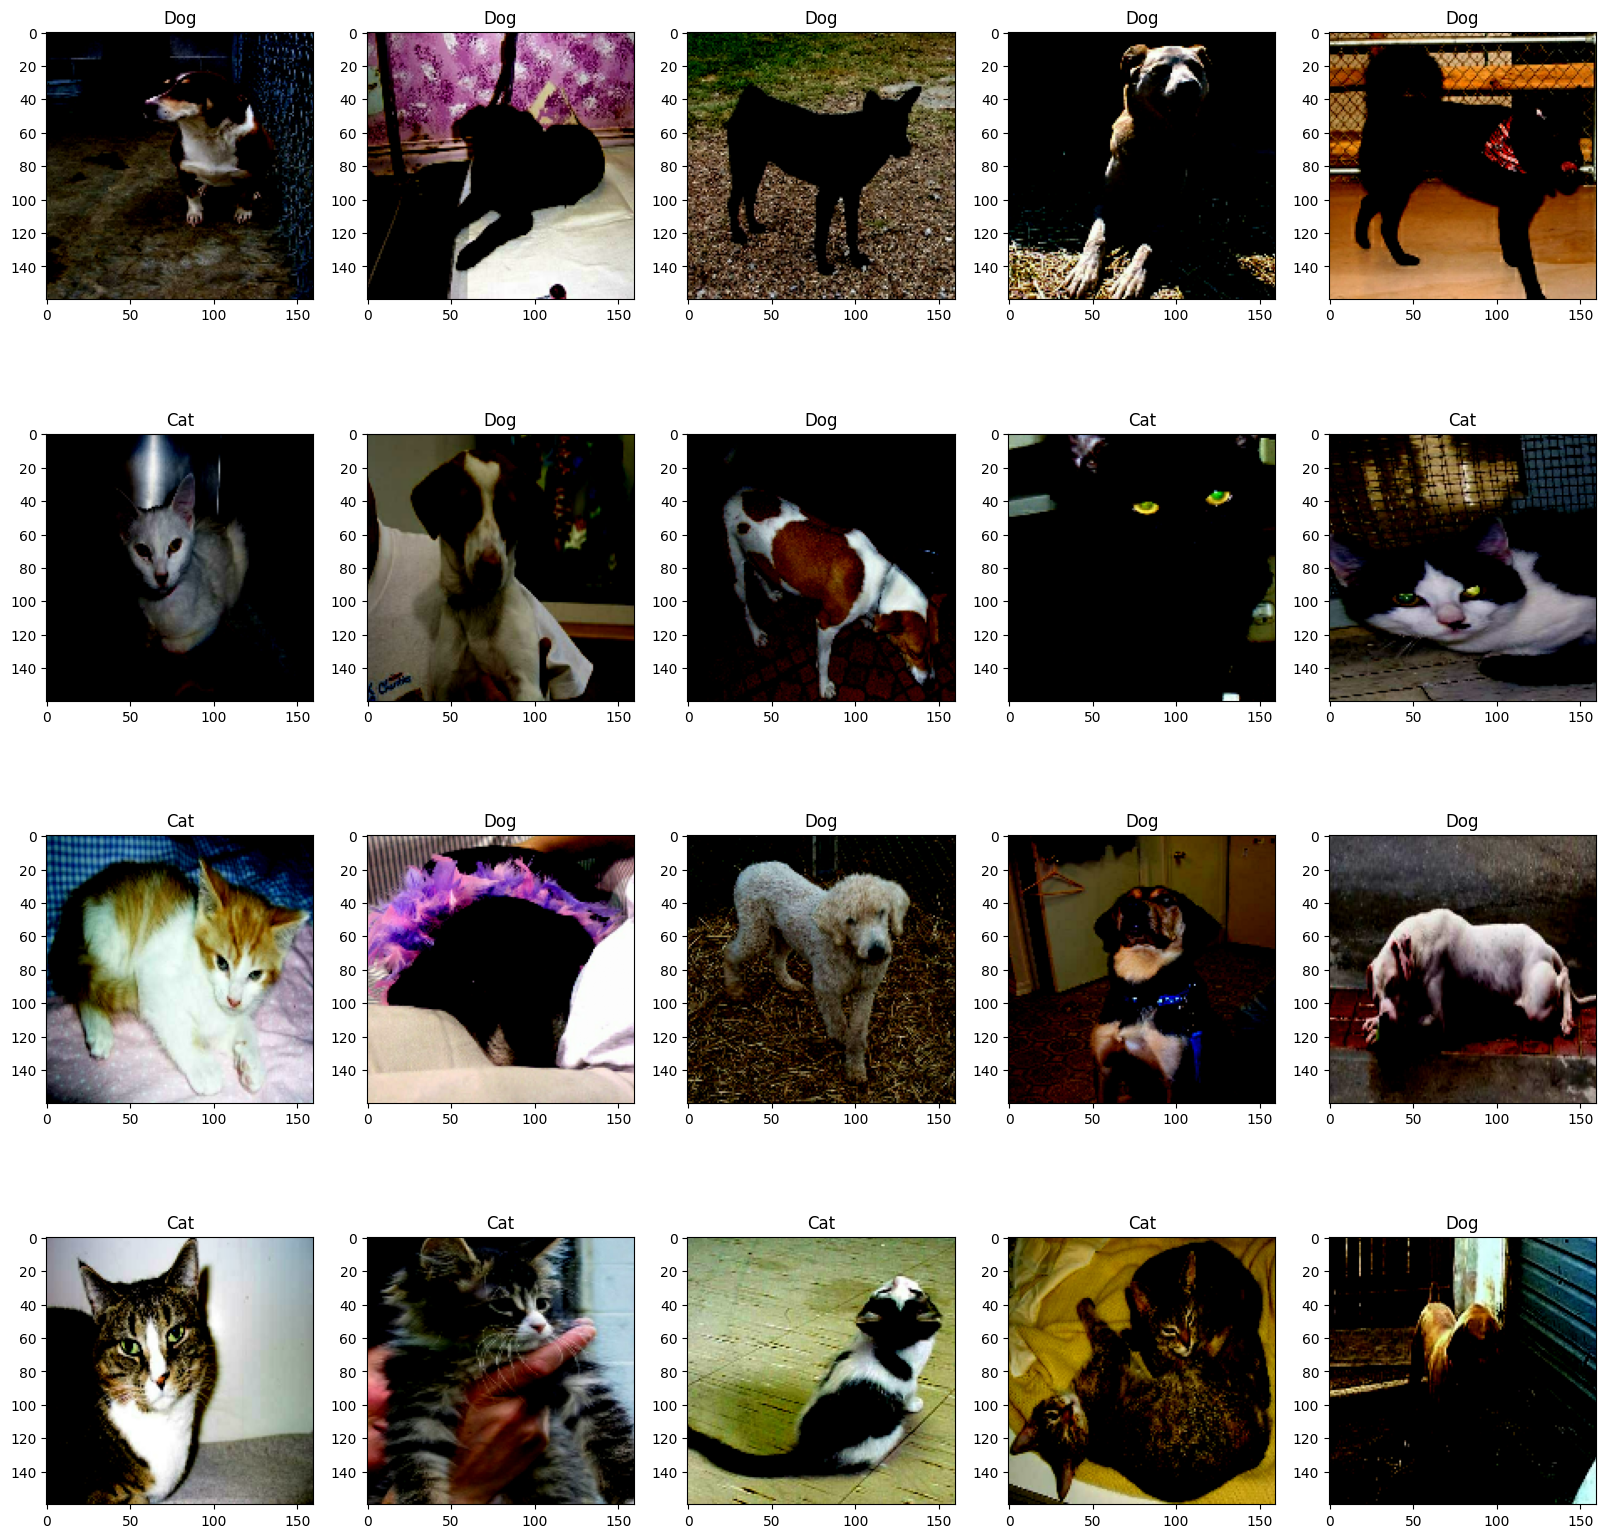

In [ ]:
plt.figure(figsize=(20,20))
for images,labels in train_dataset.take(1):
  for n in range(20):
    plt.subplot(4,5,n+1)
    plt.imshow(images[n])
    plt.title(class_names[labels[n]])

In [ ]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2)
])

using mobilenet.v2(mnv2)


```
# This is the point where it gets specific for feature extraction. above code can be used in fine tuning too
```





In [ ]:
base_model=tf.keras.applications.MobileNetV2(input_shape=(160,160,3),include_top=False, weights='imagenet')
base_model.trainable=False
#include_top and .trainable very impt!!! specific for feature extration.
#when it is false it will not include the classification layers at the top of the model

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
len(base_model.layers)

154

In [ ]:
tnmodel=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(160,160,3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1,activation='sigmoid')#because binary dataset
])

In [ ]:
tnmodel.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['binary_accuracy'])#because 2 classes
history=tnmodel.fit(train_dataset,epochs=10)
test_loss,test_accuracy=tnmodel.evaluate(test_dataset)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)

In [ ]:
for images,labels in test_dataset.take(1):
  predictions=tnmodel.predict(images)
  plt.figure(figsize=(15,15))
  for n in range(9):
    plt.subplot(3,3,n+1)
    plt.imshow(images[n])
    prediction=predictions[n]
    if prediction>0.5:
      value=1
    else:
      value=0
    plt.xlabel("Actual: "+str(class_names[labels[n]]))
    plt.ylabel("Predicted: "+class_names[value])

*Transfer Learning: Fine Tuning*

In [ ]:
base_model=tf.keras.applications.MobileNetV2(input_shape=(160,160,3),include_top=False, weights='imagenet')
base_model.trainable=True
for layer in base_model.layers[0:100]:
  layer.trainable=False #setting each of the layers to false so we only needt o train the top(last) 54 layers
#yeah this is only only(important) difference between fine tuning and feature extraction lol

In [ ]:
tnmodel=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(160,160,3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1,activation='sigmoid')#because binary dataset
])

In [ ]:
tnmodel.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['binary_accuracy'])#because 2 classes
history=tnmodel.fit(train_dataset,epochs=10)
test_loss,test_accuracy=tnmodel.evaluate(test_dataset)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)

In [ ]:
for images,labels in test_dataset.take(1):
  predictions=tnmodel.predict(images)
  plt.figure(figsize=(15,15))
  for n in range(9):
    plt.subplot(3,3,n+1)
    plt.imshow(images[n])
    prediction=predictions[n]
    if prediction>0.5:
      value=1
    else:
      value=0
    plt.xlabel("Actual: "+str(class_names[labels[n]]))
    plt.ylabel("Predicted: "+class_names[value])